# 面向 AI 辅助学习的增量价值评价：Notebook 复现材料
## 当前结论
这组 Notebook 将原始证据、认知标注、识别边界、指标、反例和教育建议串成可离线复算的 A–E 链。
模型与人审观察固定至 t3 及同题复核记录；`results/final-analysis/summary.json` 与十张聚合 CSV 连接各章。
未完成结果保持空值，合成实验、真实观察与条件推演分别标记。

## 范围与方法
阅读顺序：**00 → 01 → 08 → 02 → 09 → 03 → 04 → 05 → 06 → 07**。
01/08 建立源记录与回合分母，02/09 建立 A 的候选与误差，03 将误差条件化，04 界定 B 的可估计量，05 建立 C，06 用 D 回验，07 生成 E 的条件性行动。
合成实验与真实观察分开标注。Notebook 默认离线运行，每本使用独立内核。
### 关键假设
日志的任务要求层级不能直接解释成学生能力或学习增量。各学期的观察窗口和可用字段不同。

<!-- concept-illustration-v1:process-overview -->
### 研究流程

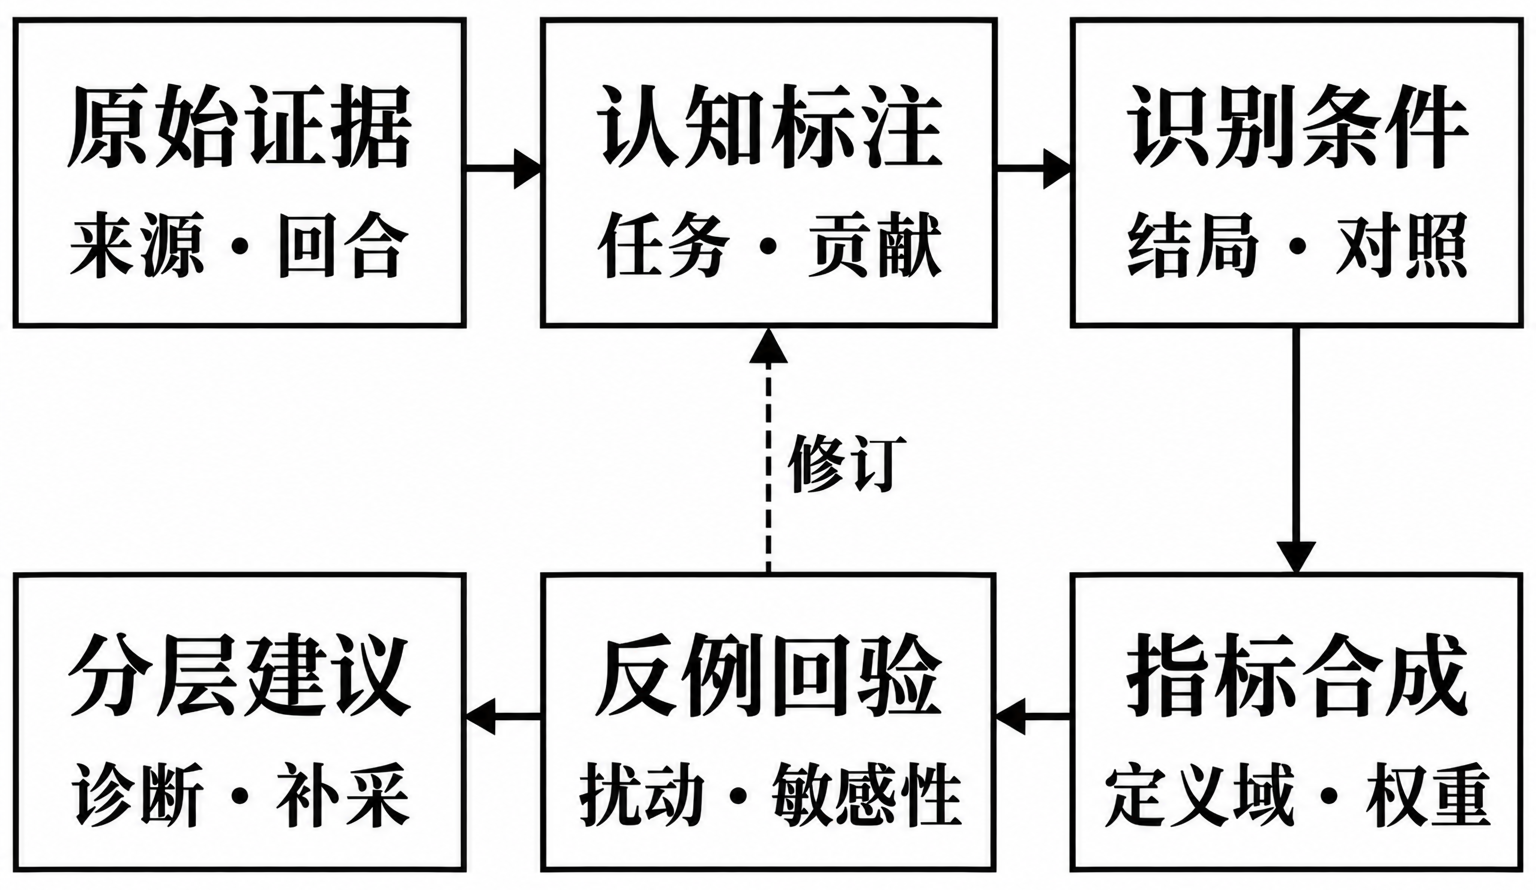

研究依次检查证据、标签、识别条件和指标定义域，再以反例回验约束建议强度。概念图说明方法关系，实验状态以本页结果与冻结清单为准。

In [1]:
from pathlib import Path
import sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "aiv").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aiv.notebook_materials import (
    configure_style, save_figure, export_table, research_inputs,
    final_archive_summary, load_frozen_batch, load_turn_snapshot, load_turn_plan, load_full_turn_materials,
    turn_manifest_summary, pending_results, offline_monthly, COLORS,
)
configure_style()
LIVE_API = False

## 数据与完成状态

In [2]:
evidence = research_inputs()
archive = final_archive_summary()
turns = turn_manifest_summary()
batch = load_turn_snapshot()
states = pd.DataFrame([
    {"材料": "真实首问记录", "状态": "已接入" if evidence else "本机无私有输入", "数量": int(evidence["terms"].text_records.sum()) if evidence else pd.NA, "用途": "原始记录范围"},
    {"材料": "恢复的可测评学生回合", "状态": "已校验来源" if turns else "待接入", "数量": turns["counts"]["model_eligible_student_turns"] if turns else pd.NA, "用途": "A 的测评单位"},
    {"材料": "人工最终核验", "状态": archive["status"] if archive else "本机无封存导出", "数量": archive["completed"] if archive else pd.NA, "用途": "规则与来源记录"},
    {"材料": "两快全量与两强独立复核", "状态": "冻结快照：" + batch["status"] if batch else "待冻结接入", "数量": batch["completed_real"] if batch else pd.NA, "用途": "A 的候选结果；未完成仍留空"},
    {"材料": "合成方法演示", "状态": "可复现", "数量": 7, "用途": "01–07 本的方法与性质实验"},
])
display(states.fillna("—"))
export_table(states, "material-status")

,材料,状态,数量,用途
0,真实首问记录,本机无私有输入,—,原始记录范围
1,恢复的可测评学生回合,待接入,—,A 的测评单位
2,人工最终核验,本机无封存导出,—,规则与来源记录
3,两快全量与两强独立复核,待冻结接入,—,A 的候选结果；未完成仍留空
4,合成方法演示,可复现,7,01–07 本的方法与性质实验


## 结果与论文位置

In [3]:
sections = pd.DataFrame([
    ["数据与观察范围", "01 / 08", "原始行→回合映射、时间和字段可用性", "真实聚合数据与来源哈希"],
    ["A：认知证据", "02 / 09", "两快候选、两强独立复核、覆盖与弃权", "批量结果以冻结范围为准"],
    ["人工记录与校准", "03 / 08", "封存状态、残差估计与覆盖率模拟", "真实校准值留空"],
    ["B：增量识别", "04", "已知真值模拟、真实识别条件", "学习增量当前不可识别"],
    ["C：指标与合成", "05", "权重、标签依赖和分数范围", "合成实验"],
    ["D：独立回验", "06", "固定标签操纵和文本对照缓存", "反例与失败范围"],
    ["E：教育决策", "07", "使用范围、复现和行动示例", "条件性建议"],
], columns=["论文部分", "Notebook", "图表内容", "证据状态"])
display(sections)
export_table(sections, "paper-section-map")

,论文部分,Notebook,图表内容,证据状态
0,数据与观察范围,01 / 08,原始行→回合映射、时间和字段可用性,真实聚合数据与来源哈希
1,A：认知证据,02 / 09,两快候选、两强独立复核、覆盖与弃权,批量结果以冻结范围为准
2,人工记录与校准,03 / 08,封存状态、残差估计与覆盖率模拟,真实校准值留空
3,B：增量识别,04,已知真值模拟、真实识别条件,学习增量当前不可识别
4,C：指标与合成,05,权重、标签依赖和分数范围,合成实验
5,D：独立回验,06,固定标签操纵和文本对照缓存,反例与失败范围
6,E：教育决策,07,使用范围、复现和行动示例,条件性建议


## 图表与复现入口
执行脚本会生成带筛选器的离线图表目录 `build/notebooks/index.html`，以及每张图的 PDF、SVG、PNG、来源摘要和稳定图号。真实月度图另有可筛选与缩放的离线 HTML。

In [4]:
import platform
from importlib.metadata import version
environment = {"python": platform.python_version(), "seed": 26, "live_api": LIVE_API,
               **{name: version(name) for name in ["pandas", "numpy", "matplotlib", "nbformat", "nbclient", "plotly"]}}
display(pd.DataFrame(environment.items(), columns=["项目", "版本 / 参数"]))
assert LIVE_API is False

,项目,版本 / 参数
0,python,3.13.9
1,seed,26
2,live_api,False
3,pandas,3.0.6
4,numpy,2.5.3
5,matplotlib,3.11.2
6,nbformat,5.11.1
7,nbclient,0.11.0
8,plotly,7.1.0


## 使用说明
在项目根目录执行 `.venv\Scripts\python.exe -X utf8 -B scripts/reproduce.py --notebooks`。
修改生成内容后运行 `scripts/build_research_notebooks.py`，该入口会同步挂载真实聚合分析与现场合成两例，再执行全部 Notebook。
离线执行不读取 `.env`；付费模型调用仅通过独立的 `scripts/run_full_turns.py` 入口。
结果接口见 `notebooks/README.md`。本机缺少私有输入时，08 本展示缺失状态，01–07 的方法演示仍可运行。

## 成稿论文的五张彩色数据图
下列输出直接嵌入 `results/final-analysis/` 的成稿 PNG，与论文 PDF 和 README 使用同一组图。
PNG 为 600 dpi，中文使用宋体（SimSun），西文与数字使用 Times New Roman；论文排版使用相应的矢量 PDF。
各图的可编辑计算及来源表分别保存在 02、03、05、09 本，统计分母与条件说明保持一致。

### 任务与贡献的六级分布及同回合共同候选
可编辑计算见 09 本。

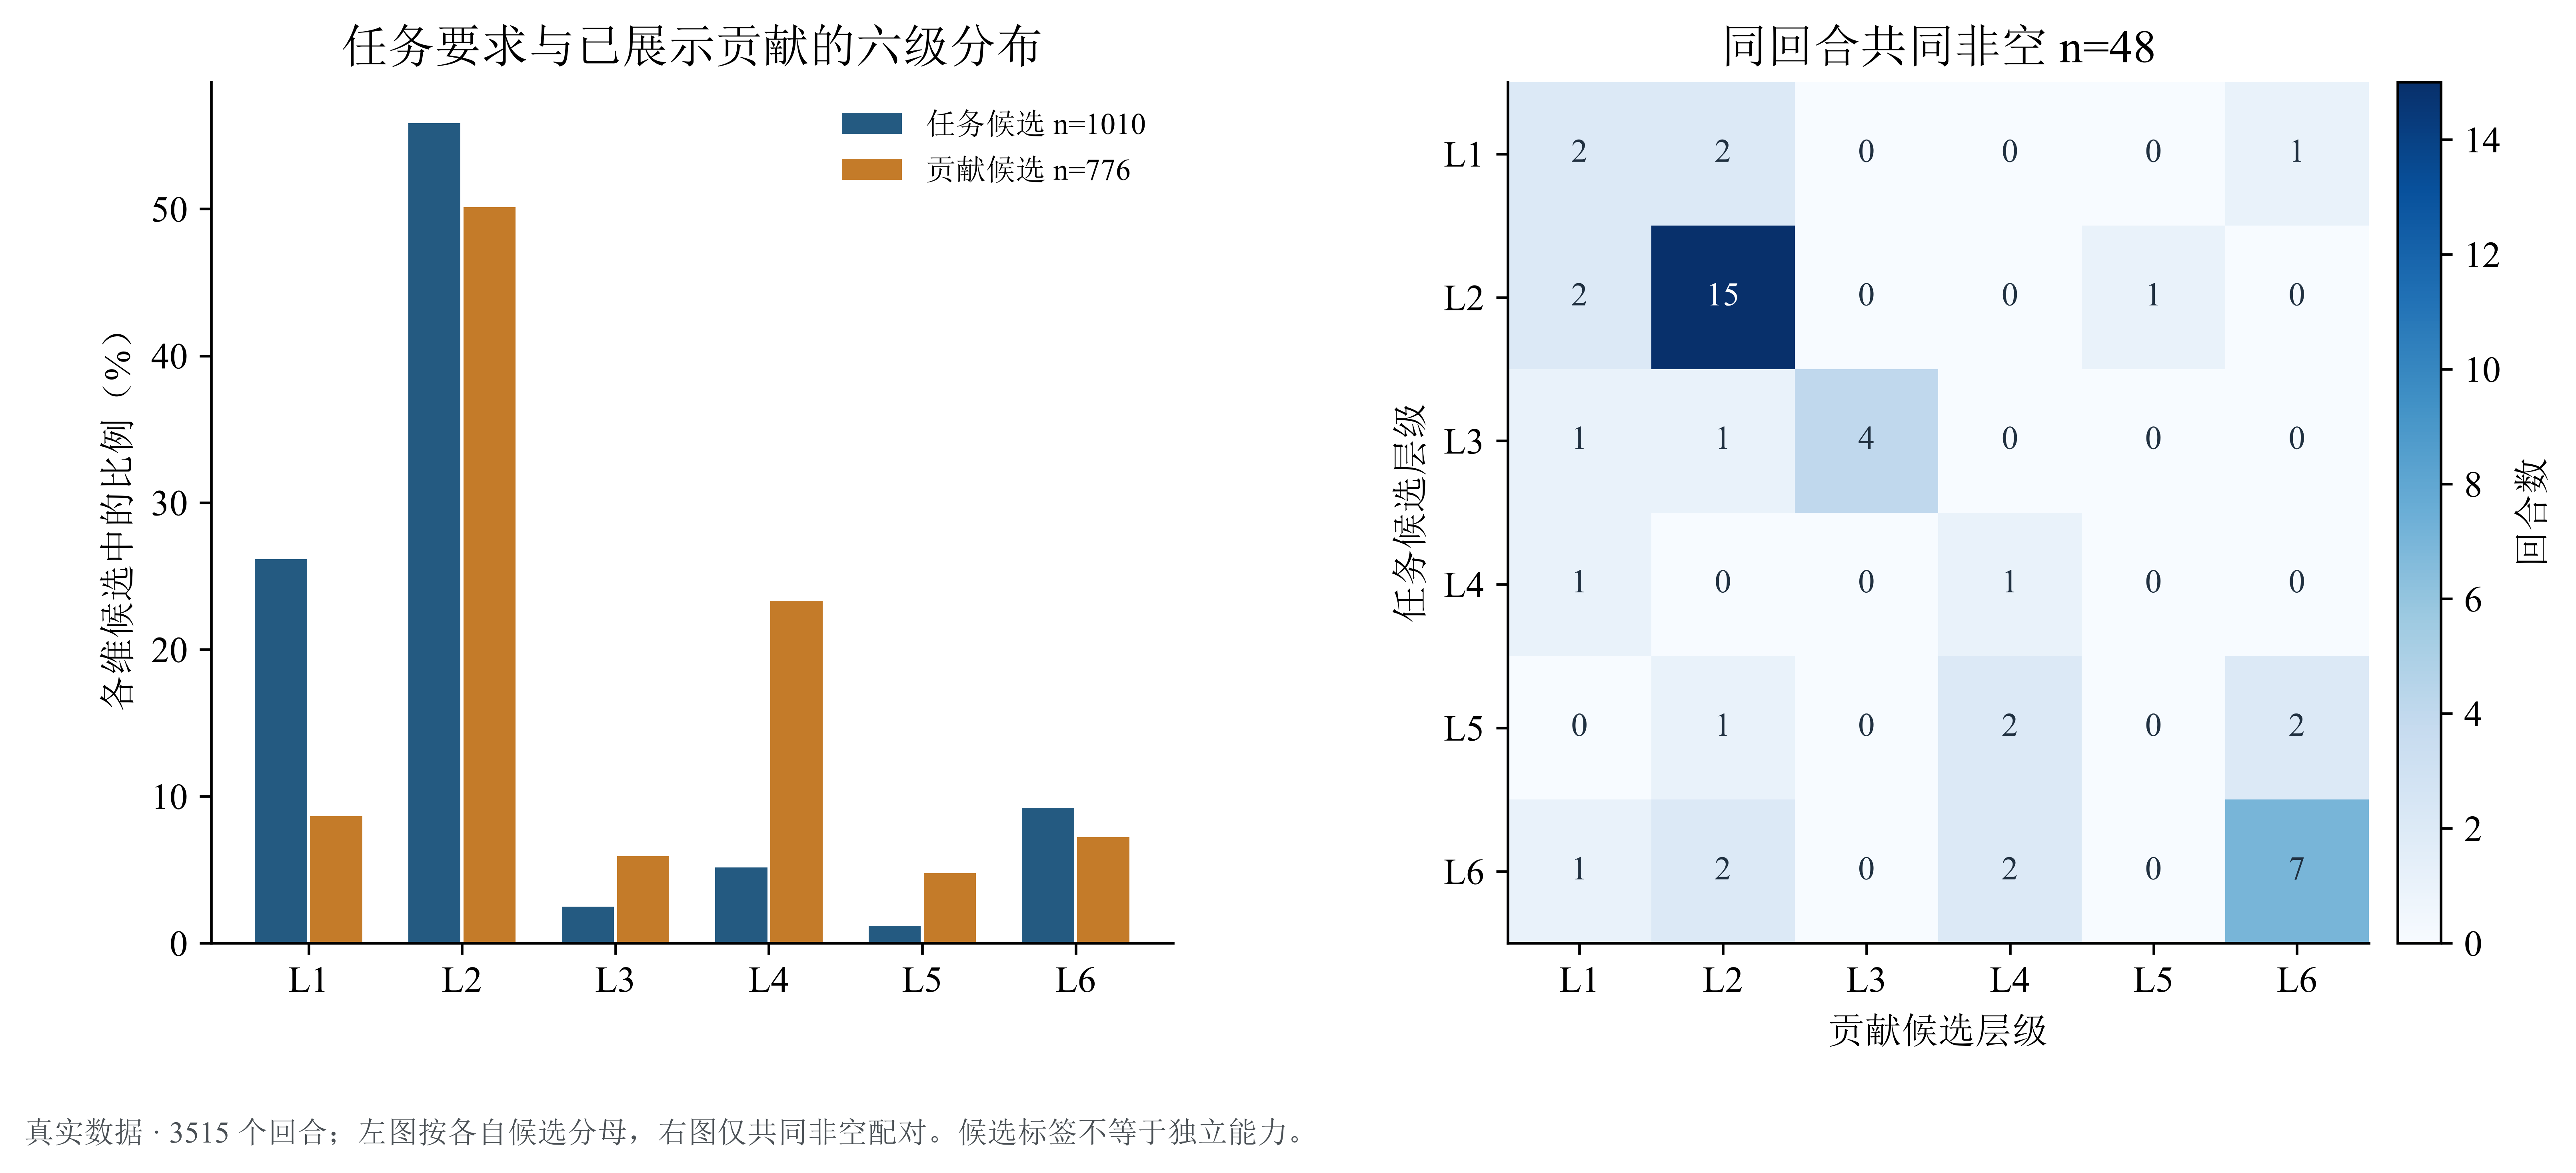

### 固定随机复核子集的流程状态比较
可编辑计算见 02 本。

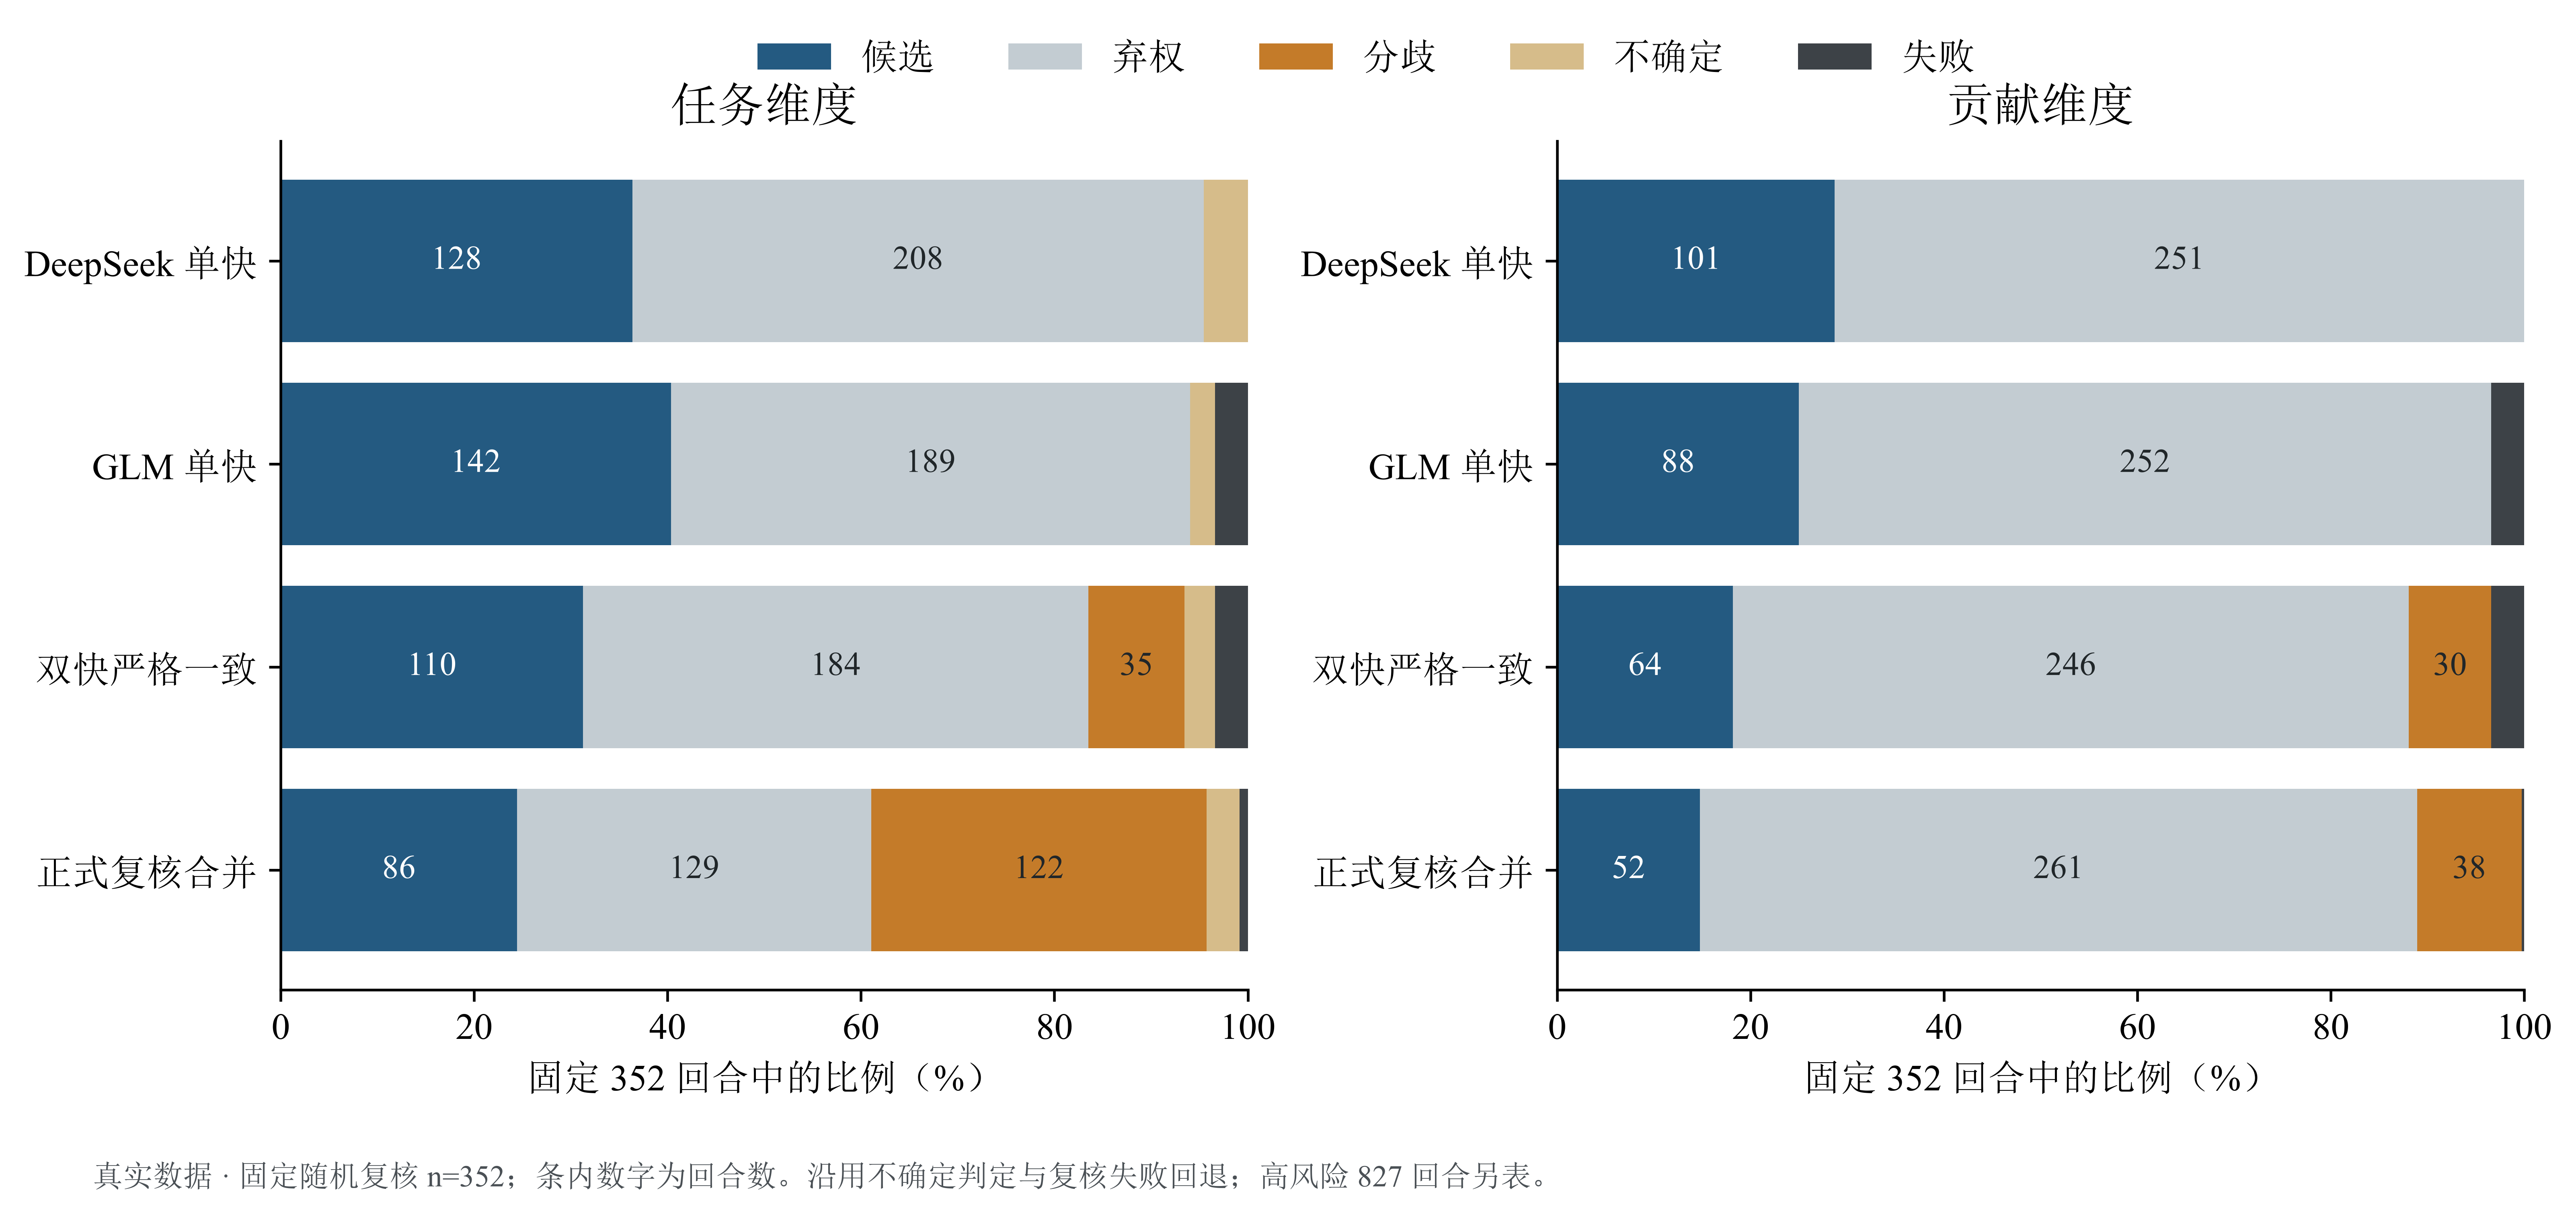

### 未知标签下的平均层级与高阶比例范围
可编辑计算见 05 本。

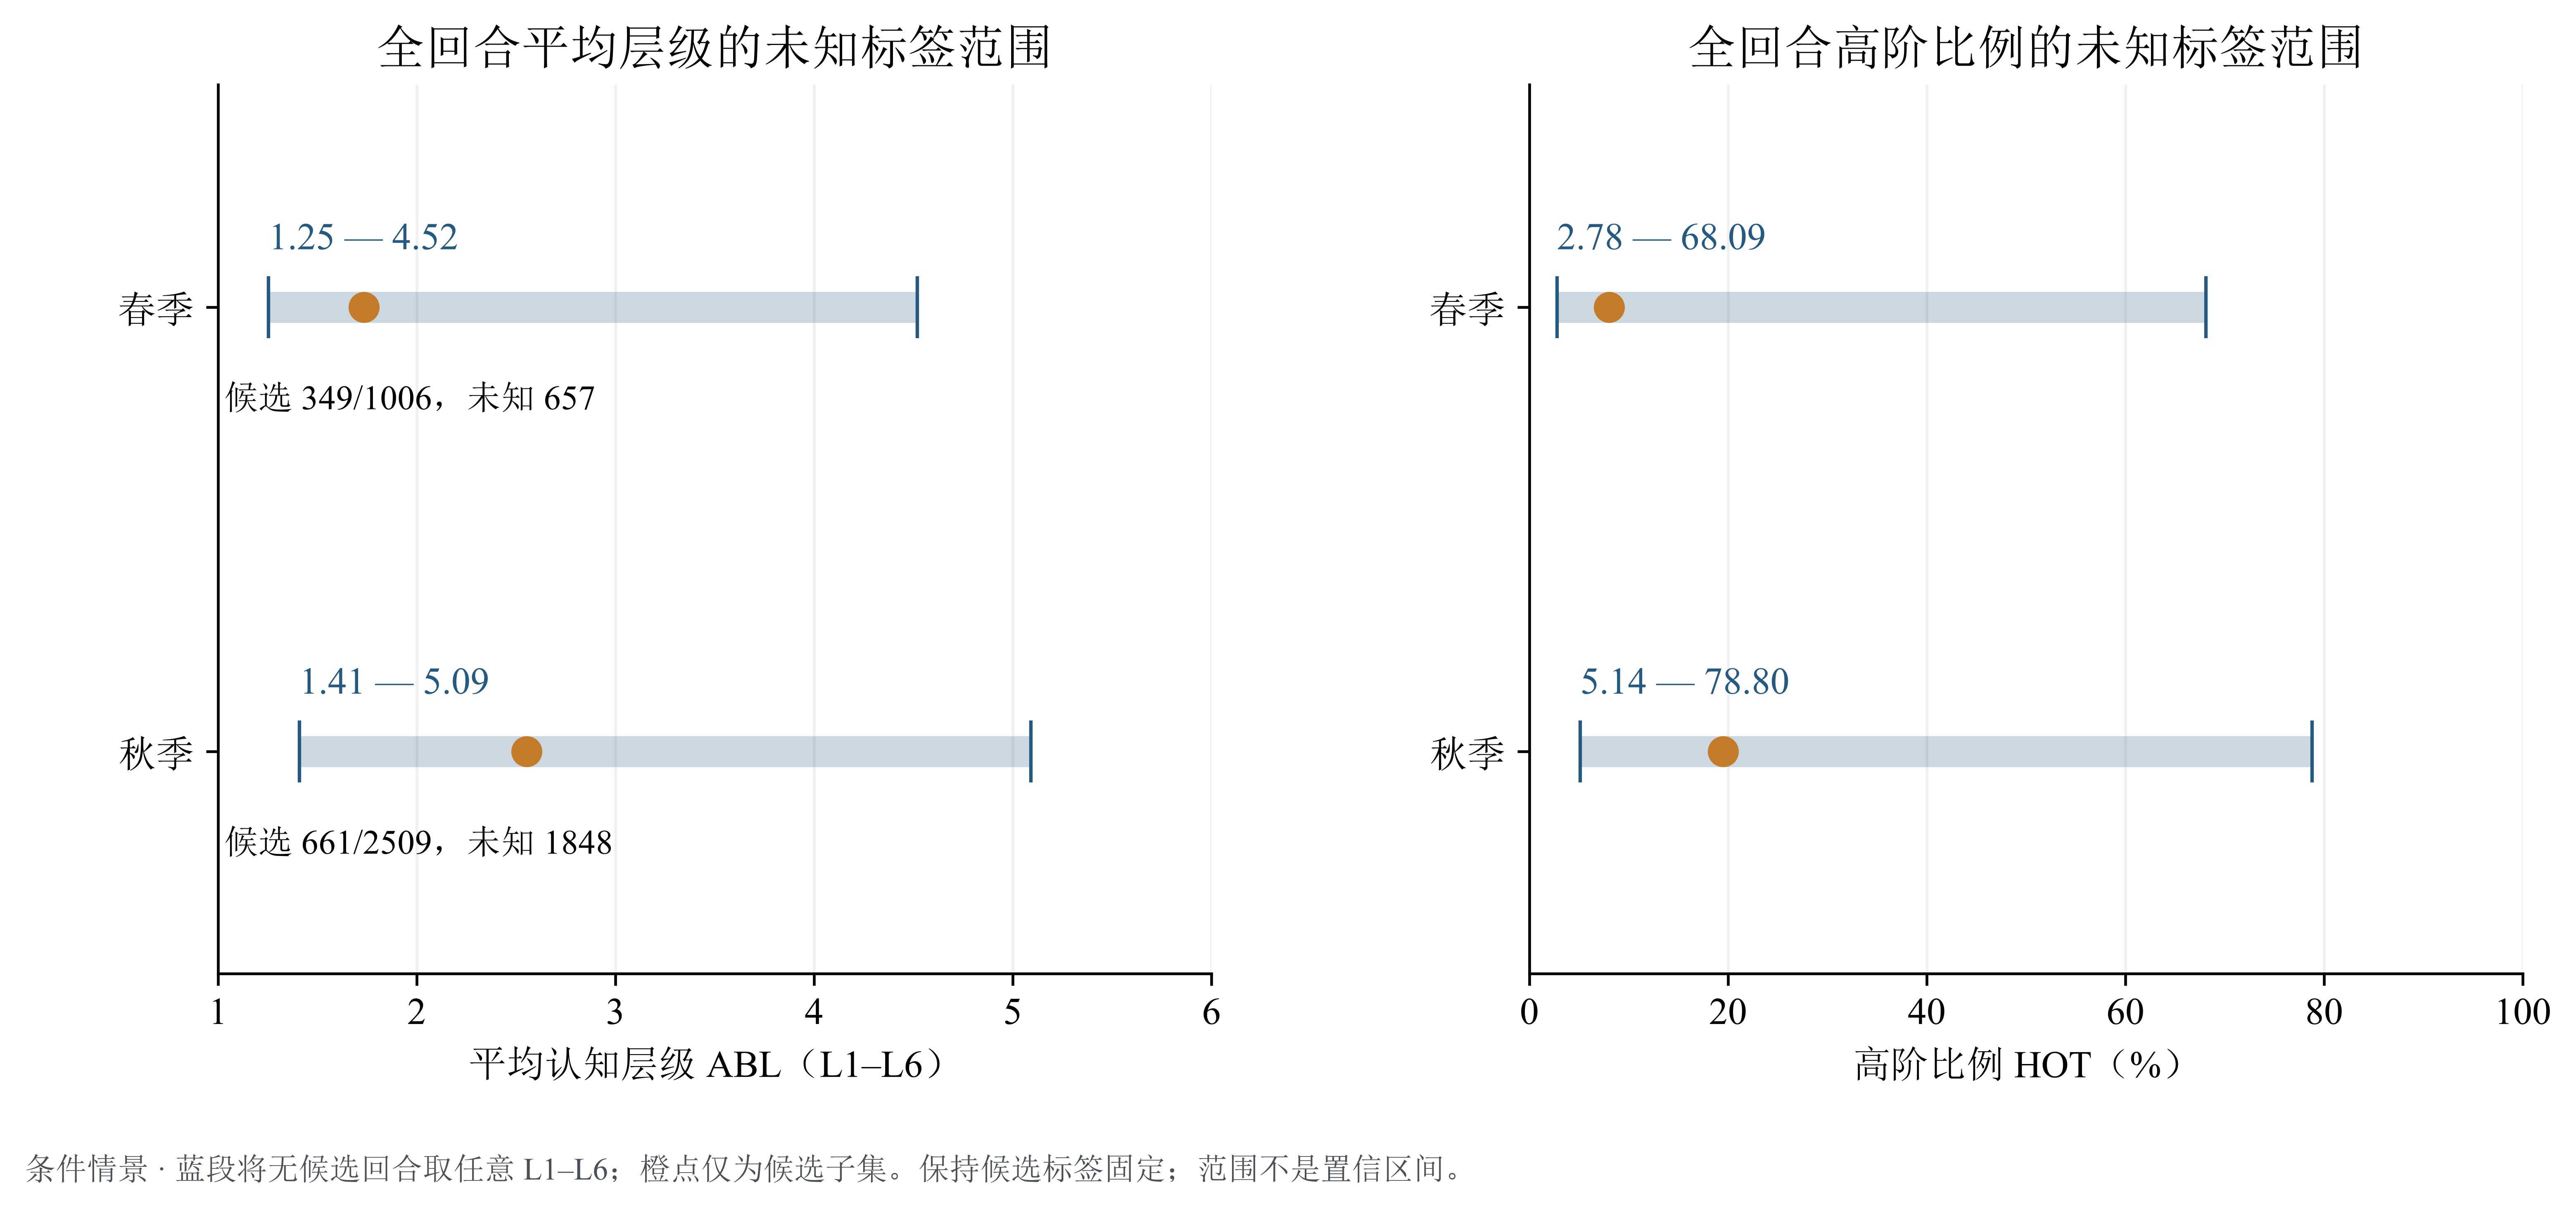

### 同题人审耗时与判断一致性
可编辑计算见 03 本。

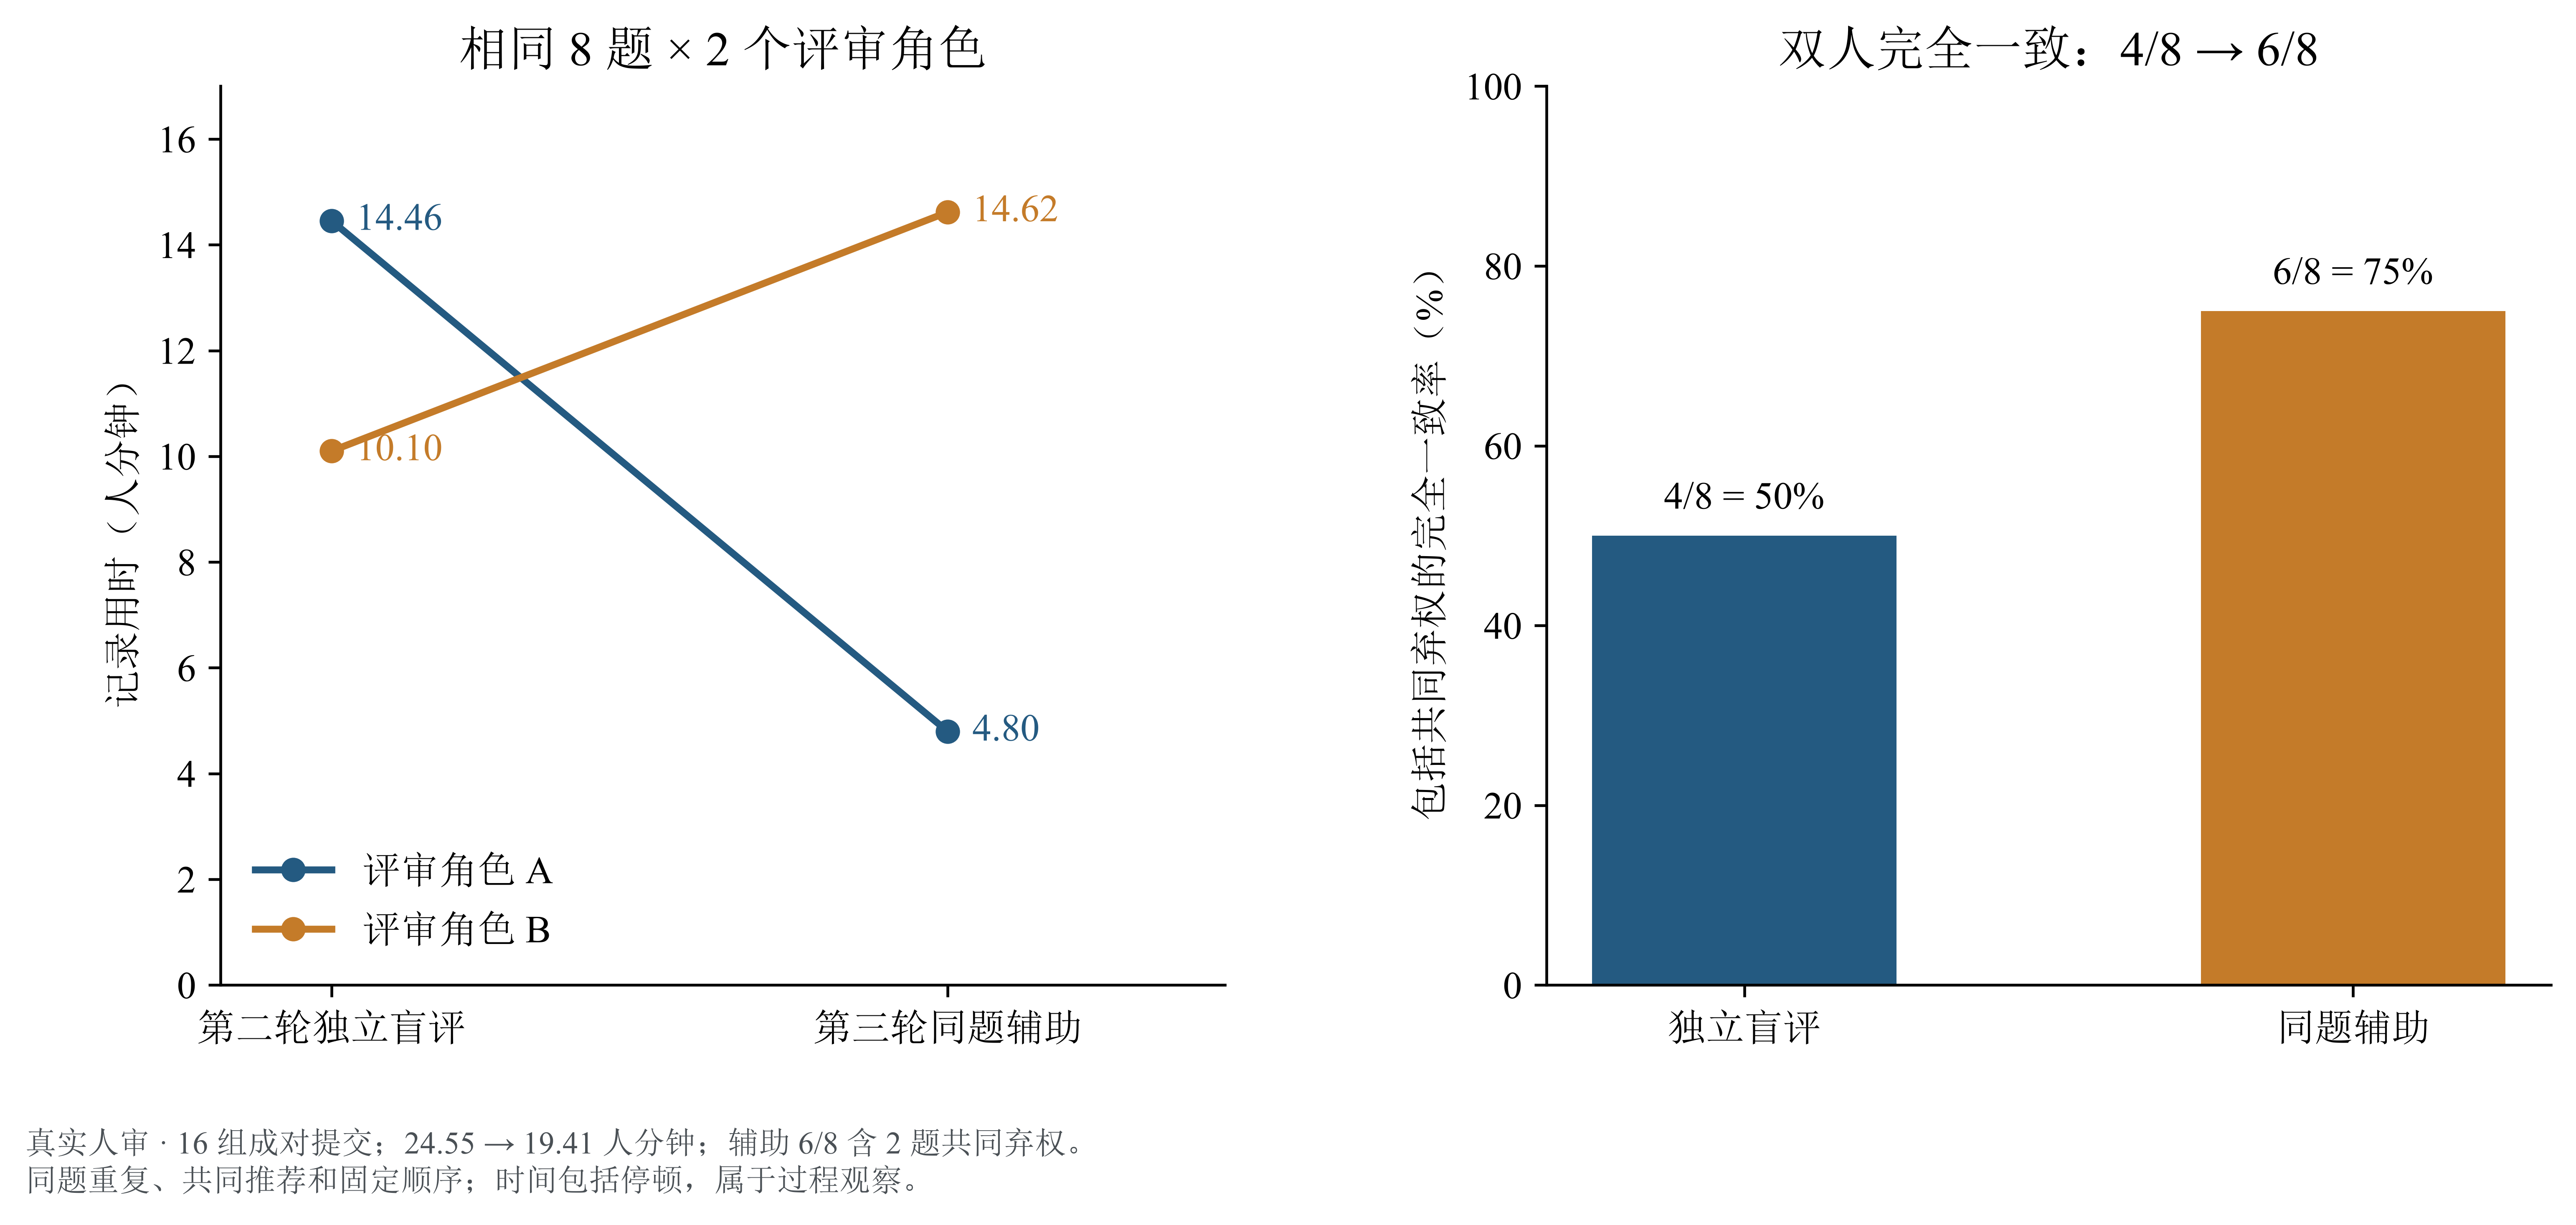

### 标签、缺失指标与权重下的条件分数范围
可编辑计算见 05 本。

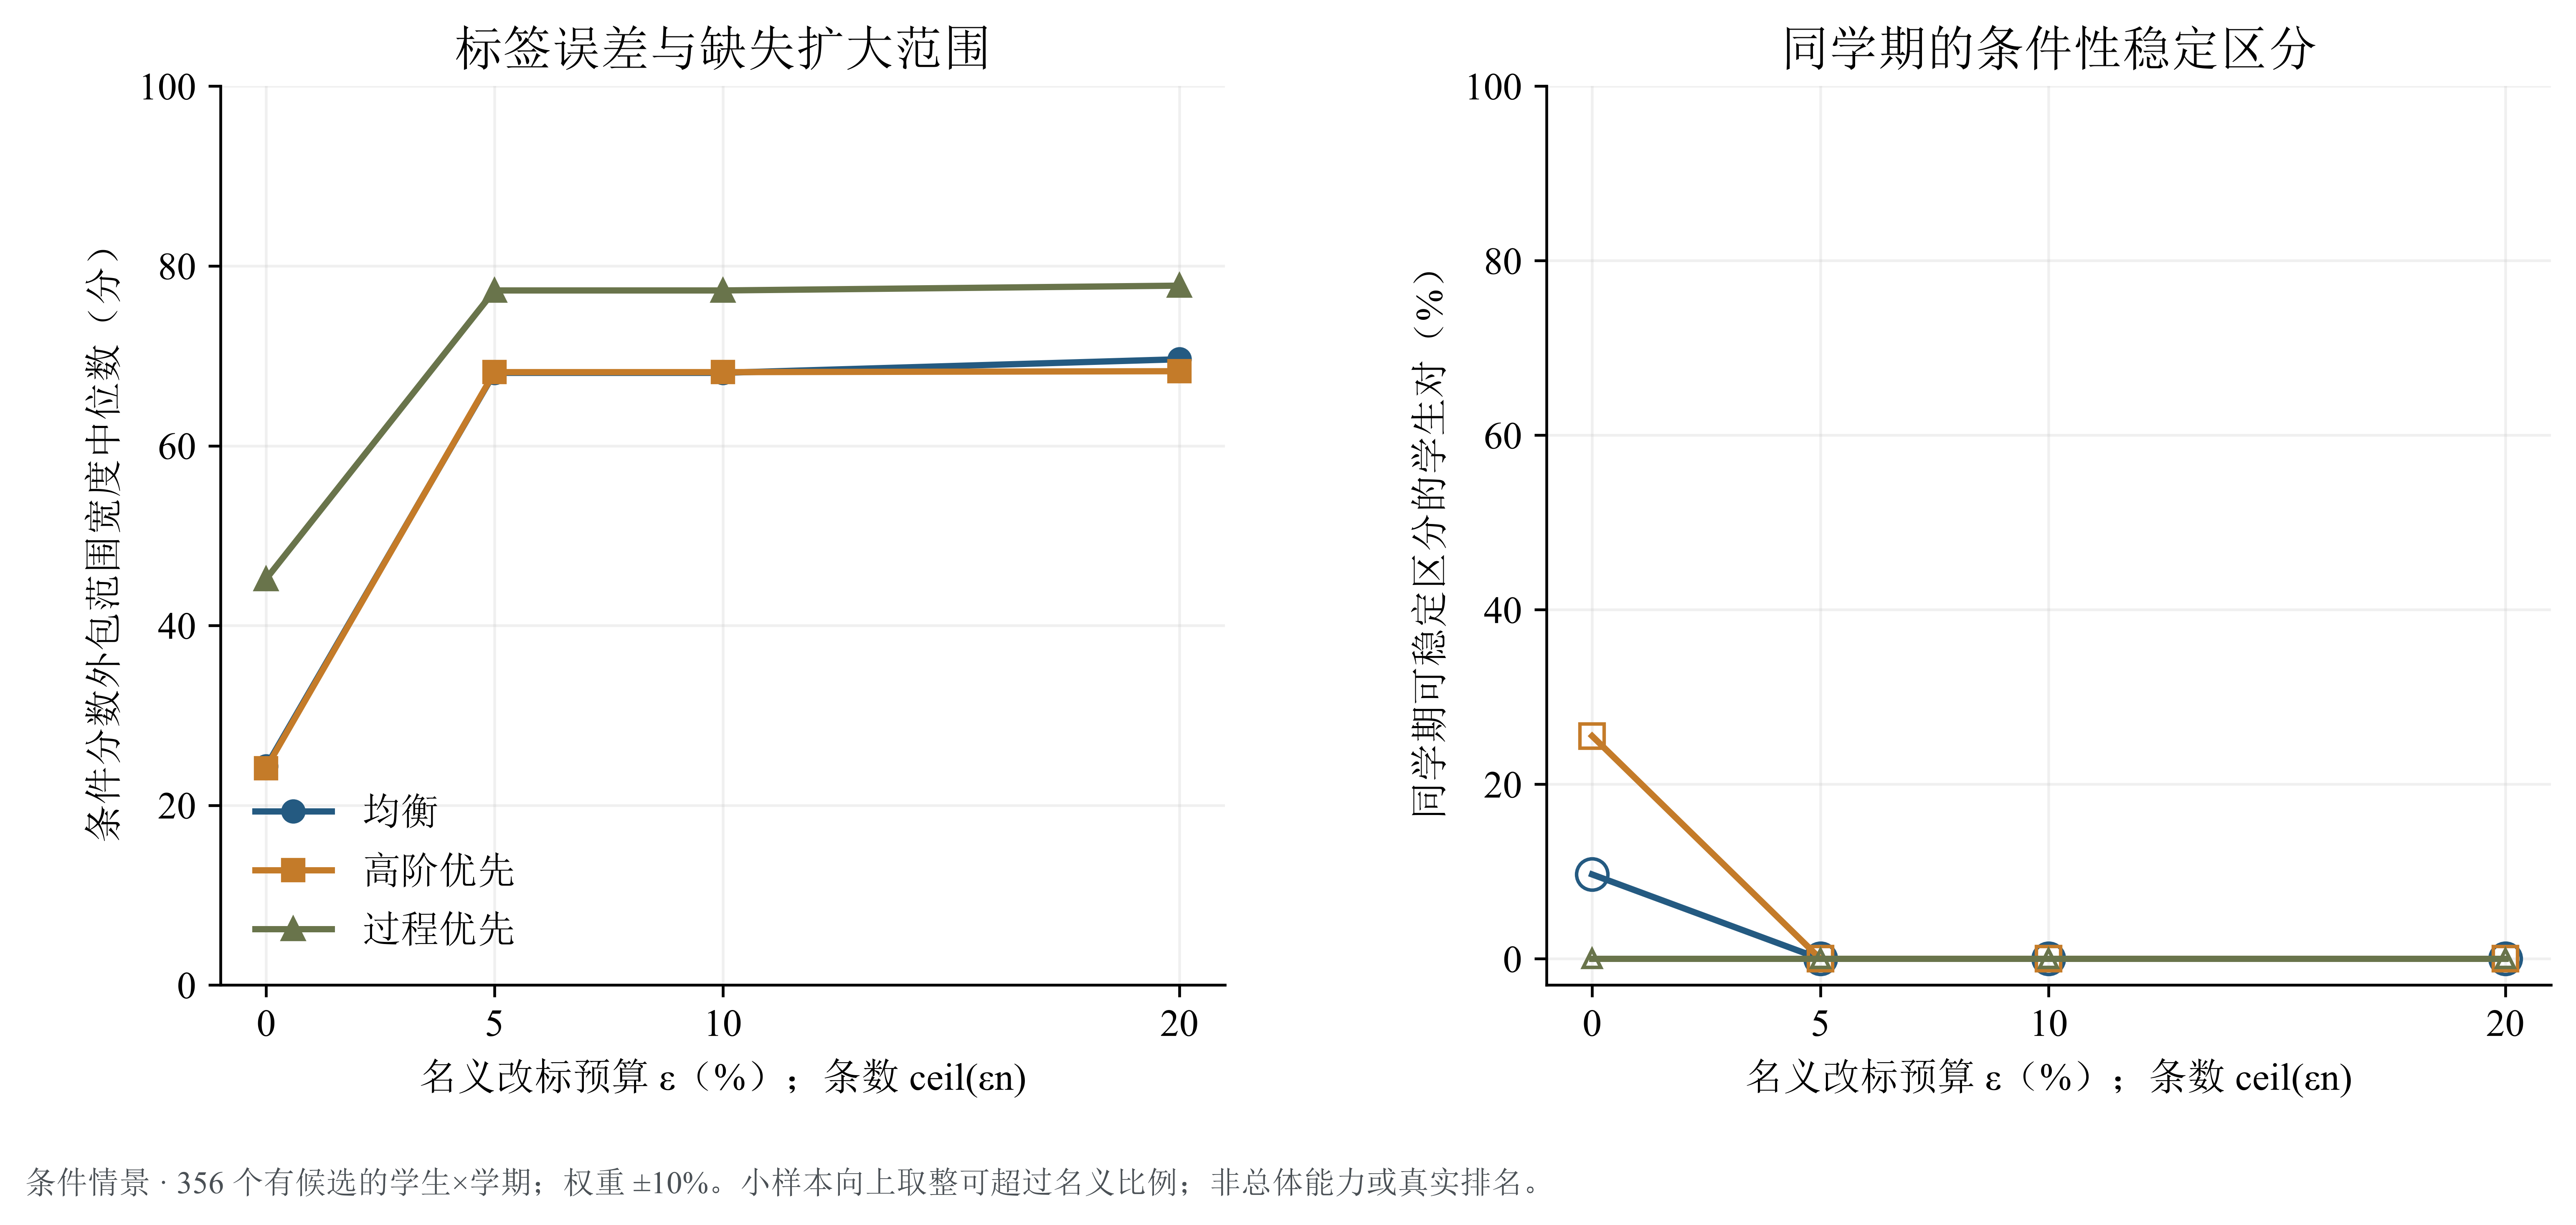

In [5]:
from IPython.display import Image, Markdown, display
from PIL import Image as PILImage
paper_figures = [
    ("fig01_dimensions", "任务与贡献的六级分布及同回合共同候选", "09"),
    ("fig02_random_flow", "固定随机复核子集的流程状态比较", "02"),
    ("fig03_unknown_labels", "未知标签下的平均层级与高阶比例范围", "05"),
    ("fig04_human_pairs", "同题人审耗时与判断一致性", "03"),
    ("fig05_score_sensitivity", "标签、缺失指标与权重下的条件分数范围", "05"),
]
for figure_id, caption, companion in paper_figures:
    figure_path = ROOT / "results" / "final-analysis" / f"{figure_id}.png"
    if not figure_path.is_file():
        display(Markdown(f"**{caption}**：本目录未附成稿图；可编辑计算见 {companion} 本。"))
        continue
    with PILImage.open(figure_path) as raster:
        assert all(abs(value - 600) < 1 for value in raster.info.get("dpi", (0, 0))), f"Unexpected DPI: {figure_path.name}"
    display(Markdown(f"### {caption}\n可编辑计算见 {companion} 本。"))
    display(Image(filename=str(figure_path), width=1100))